In [ ]:
import numpy as np
import torch
import torch.nn as nn
from torch.autograd import Variable

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


#**Model**

In [ ]:
loss_list1=[] # for drm loss graph
loss_list2=[] # for pinn loss graph
loss_list3=[] # for mix loss graph
error_list1=[]
error_list2=[]
error_list3=[]

#**DRM** ( learning rate = 10e-4 )

In [ ]:
M = 128

class Net2D(nn.Module):
    def __init__(self):
        super(Net2D, self).__init__()
        torch.manual_seed(7)  # Fix Initial Parameter
        self.hidden_layer1 = nn.Linear(3, M)
        self.hidden_layer2 = nn.Linear(M, M)
        self.hidden_layer3 = nn.Linear(M, M)
        self.hidden_layer4 = nn.Linear(M, M)
        self.output_layer = nn.Linear(M, 1)

        # Define GELU activation function
        self.gelu = nn.GELU()

    def forward(self, x, y, w):
        inputs = torch.cat([x, y, w], axis=1)  # Concatenate
        layer1_out = self.gelu(self.hidden_layer1(inputs))
        layer2_out = self.gelu(self.hidden_layer2(layer1_out))
        layer3_out = self.gelu(self.hidden_layer3(layer2_out))
        layer4_out = self.gelu(self.hidden_layer4(layer3_out))
        output = self.output_layer(layer4_out)  # For regression, no activation is used in output layer

        return output

net_2d = Net2D()
net_2d = net_2d.to(device)
optimizer = torch.optim.Adam(net_2d.parameters(), lr = 0.0001)

def drm_loss(x, y, w, net):
    # 네트워크의 출력 계산
    u = (1 - torch.sqrt(x**2 + y**2)) * net(x, y, w)

    # u를 x, y에 대해 미분 (grad_u = ∇u)
    grad_u = torch.autograd.grad(u, [x, y], grad_outputs=torch.ones_like(u), create_graph=True)

    # ∇u는 두 개의 미분 값으로 반환되므로 이를 결합하여 벡터 형식으로 만듦
    grad_u = torch.cat(grad_u, dim=1)  # grad_u는 [∂u/∂x, ∂u/∂y]

    # ∇u의 크기 계산 (|∇u|)
    grad_u_norm = torch.norm(grad_u, dim=1, keepdim=True)

    # f(w, x, y) 계산
    f = w**2 / torch.sqrt(x**2 + y**2)

    # drm loss
    energy = ((1/3) * (grad_u_norm**3) - f * u).sum() / 200000

    return energy

# 각도 theta의 분포 생성 (예: -0.99에서 0.99 사이에서 각도를 생성)
theta_collocation = np.linspace(0, 2 * np.pi, 100)

# 원 위의 (x, y) 좌표 생성
x_collocation = np.cos(theta_collocation)
y_collocation = np.sin(theta_collocation)

# 임의의 w_collocation 생성
w_collocation = np.random.uniform(0.1, 6, 20)

# 메시 그리드 생성
x_grid, y_grid, w_grid = np.meshgrid(x_collocation, y_collocation, w_collocation, indexing='ij')

# 메시 그리드를 평탄화하여 모든 조합을 생성
x_combined = x_grid.ravel().reshape(-1, 1)
y_combined = y_grid.ravel().reshape(-1, 1)
w_combined = w_grid.ravel().reshape(-1, 1)

# PyTorch 텐서로 변환
pt_x_collocation = Variable(torch.from_numpy(x_combined).float(), requires_grad=True).to(device)
pt_y_collocation = Variable(torch.from_numpy(y_combined).float(), requires_grad=True).to(device)
pt_w_collocation = Variable(torch.from_numpy(w_combined).float(), requires_grad=True).to(device)

# 반지름 1인 원 안에서 임의의 점 생성
r = np.random.uniform(0, 1, 20)  # 0과 1 사이의 값으로 반지름 선택
theta = np.random.uniform(0, 2 * np.pi, 20)  # 0과 2pi 사이에서 각도 선택

# 원 안의 (x, y) 좌표 생성
obx = r * np.cos(theta)
oby = r * np.sin(theta)
obw = np.linspace(0.1, 6, 20)

# 3D meshgrid 생성
ms_x, ms_y, ms_w = np.meshgrid(obx, oby, obw)

# 1D 배열로 변환
obx1 = np.ravel(ms_x).reshape(-1, 1)
oby1 = np.ravel(ms_y).reshape(-1, 1)
obw1 = np.ravel(ms_w).reshape(-1, 1)

# 조건 적용: x^2 + y^2 <= 1
mask = (obx1**2 + oby1**2 <= 1).flatten()
filtered_obx1 = obx1[mask]
filtered_oby1 = oby1[mask]
filtered_obw1 = obw1[mask]

ob_x = Variable(torch.from_numpy(filtered_obx1).float(), requires_grad=True).to(device)
ob_y = Variable(torch.from_numpy(filtered_oby1).float(), requires_grad=True).to(device)
ob_w = Variable(torch.from_numpy(filtered_obw1).float(), requires_grad=True).to(device)

iterations = 2000
previous_validation_loss = 99999999.0

In [ ]:
for epoch in range(iterations):
    optimizer.zero_grad() # to make the gradients zero

    drm = drm_loss(pt_x_collocation, pt_y_collocation, pt_w_collocation, net_2d)

    drm.backward() # This is for computing gradients using backward propagation
    optimizer.step() # Using Adam

    ##--------------------------------------Print relative error(Not learn)-----------------------------------------##
    if epoch % 50 == 0:
        pt_u = (1 - torch.sqrt(ob_x**2 + ob_y**2)) * net_2d(ob_x, ob_y, ob_w)

        # solution 계산
        solution = ob_w * (1 - torch.sqrt(ob_x**2 + ob_y**2))

        error_drm = ((((solution - pt_u)**2).sum()) / ((solution**2).sum()))**(0.5)

        print("Epoch : ",epoch)
        print("drm_loss : ",drm.item())
        print("Relative L2 error:", error_drm)
        print("---------------------------------------------------")

        loss_list1.append(drm.item())
        error_list1.append(error_drm.item())

net_drm=net_2d

Epoch :  0
drm_loss :  0.13797153532505035
Relative L2 error: tensor(1.0121, device='cuda:0', grad_fn=<PowBackward0>)
---------------------------------------------------
Epoch :  50
drm_loss :  -1.295818567276001
Relative L2 error: tensor(0.8545, device='cuda:0', grad_fn=<PowBackward0>)
---------------------------------------------------
Epoch :  100
drm_loss :  -3.713636875152588
Relative L2 error: tensor(0.4241, device='cuda:0', grad_fn=<PowBackward0>)
---------------------------------------------------
Epoch :  150
drm_loss :  -4.0391035079956055
Relative L2 error: tensor(0.3905, device='cuda:0', grad_fn=<PowBackward0>)
---------------------------------------------------
Epoch :  200
drm_loss :  -4.9933576583862305
Relative L2 error: tensor(0.2878, device='cuda:0', grad_fn=<PowBackward0>)
---------------------------------------------------
Epoch :  250
drm_loss :  -6.299039840698242
Relative L2 error: tensor(0.2051, device='cuda:0', grad_fn=<PowBackward0>)
--------------------------

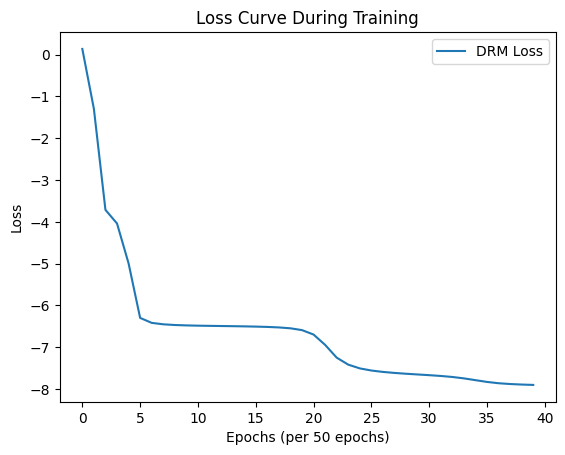

In [ ]:
import matplotlib.pyplot as plt

plt.plot(loss_list1, label='DRM Loss')

plt.title('Loss Curve During Training')
plt.xlabel('Epochs (per 50 epochs)')
plt.ylabel('Loss')

plt.legend()

plt.show()

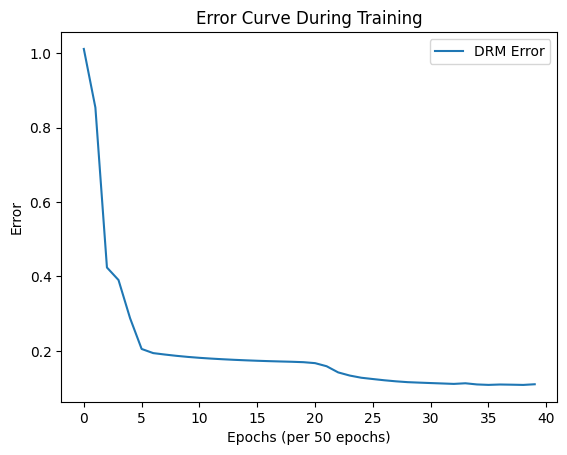

In [ ]:
import matplotlib.pyplot as plt

# 각 error_list를 플롯에 추가
plt.plot(error_list1, label='DRM Error')

plt.title('Error Curve During Training')
plt.xlabel('Epochs (per 50 epochs)')
plt.ylabel('Error')

# 범례 추가
plt.legend()

plt.show()

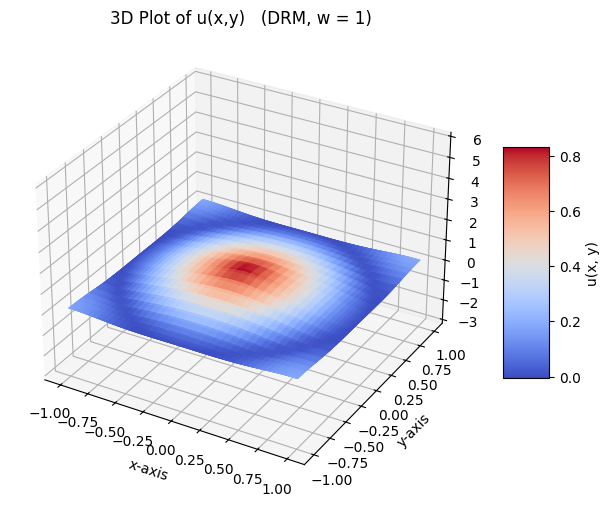

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

# Set a fixed w value
w_fixed = 1.0

# Generate theta values for a circular distribution
theta = np.linspace(0, 2 * np.pi, 100)

# Generate (x, y) coordinates on the circle
x_plot = np.cos(theta)
y_plot = np.sin(theta)

# Create a 2D grid
x_plot_grid, y_plot_grid = np.meshgrid(x_plot, y_plot)

# Flatten the grid for network input
pt_x_plot = torch.tensor(x_plot_grid.ravel(), dtype=torch.float32).to(device).view(-1, 1)
pt_y_plot = torch.tensor(y_plot_grid.ravel(), dtype=torch.float32).to(device).view(-1, 1)
pt_w_plot = torch.full((pt_x_plot.size(0), 1), w_fixed, device=device)

# Calculate u(x, y)
u_plot = (1 - torch.sqrt(pt_x_plot**2 + pt_y_plot**2)) * net_drm(pt_x_plot, pt_y_plot, pt_w_plot)

# Reshape u_plot for plotting
u_plot_reshaped = u_plot.detach().cpu().numpy().reshape(x_plot_grid.shape)

# Plotting
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(x_plot_grid, y_plot_grid, u_plot_reshaped, cmap='coolwarm')  # Set color map to 'coolwarm'
ax.set_zlim(-3,6)

# Add color bar
cbar = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)
cbar.set_label("u(x, y)")

# Set labels and title
ax.set_xlabel("x-axis")
ax.set_ylabel("y-axis")
ax.set_title("3D Plot of u(x,y)   (DRM, w = 1)")

plt.show()

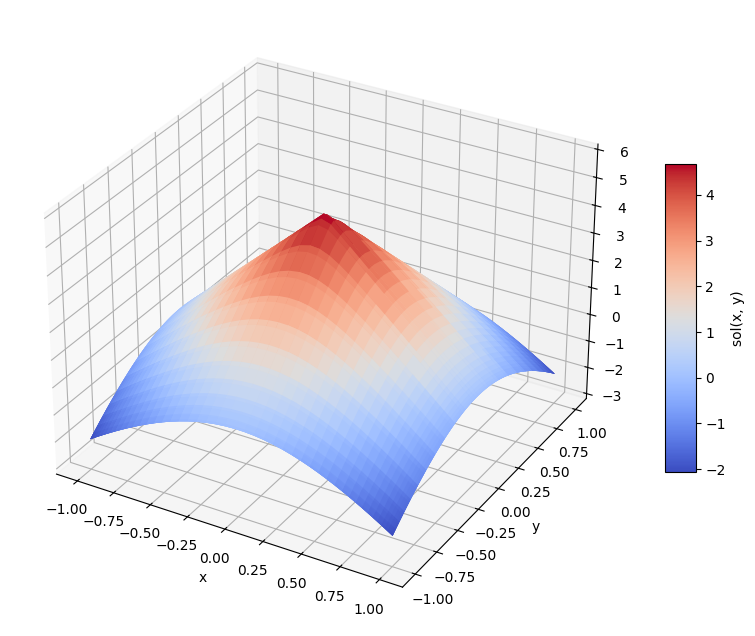

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 고정된 w 값 설정
w_fixed = 5.0

# 각도 theta의 분포 생성
theta = np.linspace(0, 2 * np.pi, 100)

# 원 위의 (x, y) 좌표 생성
x_plot = np.cos(theta)
y_plot = np.sin(theta)

# 2D 그리드 생성
x_plot_grid, y_plot_grid = np.meshgrid(x_plot, y_plot)

# 그리드 형태를 1D로 변환하여 네트워크에 넣을 준비
pt_x_plot = torch.tensor(x_plot_grid.ravel(), dtype=torch.float32).to(device).view(-1, 1)
pt_y_plot = torch.tensor(y_plot_grid.ravel(), dtype=torch.float32).to(device).view(-1, 1)
pt_w_plot = torch.full((pt_x_plot.size(0), 1), w_fixed, device=device)

# u(x, y) 계산
sol_plot = pt_w_plot * (1 - torch.sqrt(pt_x_plot**2 + pt_y_plot**2))

# u_plot을 2D 형태로 변환하여 그래프에 사용할 수 있도록 함
sol_plot_reshaped = sol_plot.detach().cpu().numpy().reshape(x_plot_grid.shape)

# 그래프 그리기
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(x_plot_grid, y_plot_grid, sol_plot_reshaped, cmap='coolwarm')
ax.set_zlim(-3,6)

# 색상바 추가
cbar = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)
cbar.set_label("sol(x, y)")

# 레이블 설정
ax.set_xlabel("x")
ax.set_ylabel("y")
#ax.set_title('3D Plot of sol(x, y)   w = 1')

plt.show()

#**PINN** ( learning rate = 10e-3 )

In [ ]:
M = 128

class Net2D(nn.Module):
    def __init__(self):
        super(Net2D, self).__init__()
        torch.manual_seed(7)  # Fix Initial Parameter
        self.hidden_layer1 = nn.Linear(3, M)
        self.hidden_layer2 = nn.Linear(M, M)
        self.hidden_layer3 = nn.Linear(M, M)
        self.hidden_layer4 = nn.Linear(M, M)
        self.output_layer = nn.Linear(M, 1)

        # Define GELU activation function
        self.gelu = nn.GELU()

    def forward(self, x, y, w):
        inputs = torch.cat([x, y, w], axis=1)  # Concatenate
        layer1_out = self.gelu(self.hidden_layer1(inputs))
        layer2_out = self.gelu(self.hidden_layer2(layer1_out))
        layer3_out = self.gelu(self.hidden_layer3(layer2_out))
        layer4_out = self.gelu(self.hidden_layer4(layer3_out))
        output = self.output_layer(layer4_out)  # For regression, no activation is used in output layer

        return output

net_2d = Net2D()
net_2d = net_2d.to(device)
optimizer = torch.optim.Adam(net_2d.parameters(), lr = 0.001)

def pinn_loss(x, y, w, net):
    # 네트워크의 출력 계산 (u 값)
    u = (1 - torch.sqrt(x**2 + y**2)) * net(x, y, w)

    # u를 x, y에 대해 미분 (grad_u = ∇u)
    grad_u = torch.autograd.grad(u, [x, y], grad_outputs=torch.ones_like(u), create_graph=True)

    # ∇u는 두 개의 미분 값으로 반환되므로 이를 결합하여 벡터 형식으로 만듦
    grad_u = torch.cat(grad_u, dim=1)  # grad_u는 [∂u/∂x, ∂u/∂y]

    # ∇u의 크기 계산 (|∇u|)
    grad_u_norm = torch.norm(grad_u, dim=1, keepdim=True)

    # 3-Laplacian: div(|∇u| ∇u)를 계산 (x, y에 대해서만)
    div_term = grad_u_norm * grad_u
    div_x = torch.autograd.grad(div_term[:, 0], x, grad_outputs=torch.ones_like(div_term[:, 0]), create_graph=True)[0]
    div_y = torch.autograd.grad(div_term[:, 1], y, grad_outputs=torch.ones_like(div_term[:, 1]), create_graph=True)[0]

    # 발산은 x, y에 대한 미분의 합
    div = div_x + div_y

    # f(w, x, y) 계산
    f = w**2 / torch.sqrt(x**2 + y**2)

    # PINN loss = MSE(div + f)
    loss = torch.mean((div + f)**2)

    return loss

# 각도 theta의 분포 생성 (예: -0.99에서 0.99 사이에서 각도를 생성)
theta_collocation = np.linspace(0, 2 * np.pi, 100)

# 원 위의 (x, y) 좌표 생성
x_collocation = np.cos(theta_collocation)
y_collocation = np.sin(theta_collocation)

# 임의의 w_collocation 생성
w_collocation = np.random.uniform(0.1, 6, 20)

# 메시 그리드 생성
x_grid, y_grid, w_grid = np.meshgrid(x_collocation, y_collocation, w_collocation, indexing='ij')

# 메시 그리드를 평탄화하여 모든 조합을 생성
x_combined = x_grid.ravel().reshape(-1, 1)
y_combined = y_grid.ravel().reshape(-1, 1)
w_combined = w_grid.ravel().reshape(-1, 1)

# PyTorch 텐서로 변환
pt_x_collocation = Variable(torch.from_numpy(x_combined).float(), requires_grad=True).to(device)
pt_y_collocation = Variable(torch.from_numpy(y_combined).float(), requires_grad=True).to(device)
pt_w_collocation = Variable(torch.from_numpy(w_combined).float(), requires_grad=True).to(device)

# 반지름 1인 원 안에서 임의의 점 생성
r = np.random.uniform(0, 1, 20)  # 0과 1 사이의 값으로 반지름 선택
theta = np.random.uniform(0, 2 * np.pi, 20)  # 0과 2pi 사이에서 각도 선택

# 원 안의 (x, y) 좌표 생성
obx = r * np.cos(theta)
oby = r * np.sin(theta)
obw = np.linspace(0,1, 6, 20)

# 3D meshgrid 생성
ms_x, ms_y, ms_w = np.meshgrid(obx, oby, obw)

# 1D 배열로 변환
obx1 = np.ravel(ms_x).reshape(-1, 1)
oby1 = np.ravel(ms_y).reshape(-1, 1)
obw1 = np.ravel(ms_w).reshape(-1, 1)

# 조건 적용: x^2 + y^2 <= 1
mask = (obx1**2 + oby1**2 <= 1).flatten()
filtered_obx1 = obx1[mask]
filtered_oby1 = oby1[mask]
filtered_obw1 = obw1[mask]

ob_x = Variable(torch.from_numpy(filtered_obx1).float(), requires_grad=True).to(device)
ob_y = Variable(torch.from_numpy(filtered_oby1).float(), requires_grad=True).to(device)
ob_w = Variable(torch.from_numpy(filtered_obw1).float(), requires_grad=True).to(device)

iterations = 2000
previous_validation_loss = 99999999.0

In [ ]:
for epoch in range(iterations):
    optimizer.zero_grad() # to make the gradients zero

    pinn = pinn_loss(pt_x_collocation, pt_y_collocation, pt_w_collocation, net_2d)

    pinn.backward() # This is for computing gradients using backward propagation
    optimizer.step() # Using Adam

    ##--------------------------------------Print relative error(Not learn)-----------------------------------------##
    if epoch % 50 == 0:
        pt_u = (1 - torch.sqrt(ob_x**2 + ob_y**2)) * net_2d(ob_x, ob_y, ob_w)

        # solution 계산
        solution = ob_w * (1 - torch.sqrt(ob_x**2 + ob_y**2))

        error_pinn = ((((solution - pt_u)**2).sum()) / ((solution**2).sum()))**(0.5)

        print("Epoch : ",epoch)
        print("pinn_loss : ",pinn.item())
        print("Relative L2 error:", error_pinn)
        print("---------------------------------------------------")

        loss_list2.append(pinn.item())
        error_list2.append(error_pinn.item())

net_pinn=net_2d

Epoch :  0
pinn_loss :  1494.232177734375
Relative L2 error: tensor(1.0232, device='cuda:0', grad_fn=<PowBackward0>)
---------------------------------------------------
Epoch :  50
pinn_loss :  4.365905284881592
Relative L2 error: tensor(0.3120, device='cuda:0', grad_fn=<PowBackward0>)
---------------------------------------------------
Epoch :  100
pinn_loss :  0.2752391993999481
Relative L2 error: tensor(0.2965, device='cuda:0', grad_fn=<PowBackward0>)
---------------------------------------------------
Epoch :  150
pinn_loss :  0.10514625906944275
Relative L2 error: tensor(0.3089, device='cuda:0', grad_fn=<PowBackward0>)
---------------------------------------------------
Epoch :  200
pinn_loss :  0.05702917277812958
Relative L2 error: tensor(0.2645, device='cuda:0', grad_fn=<PowBackward0>)
---------------------------------------------------
Epoch :  250
pinn_loss :  0.028031956404447556
Relative L2 error: tensor(0.1698, device='cuda:0', grad_fn=<PowBackward0>)
---------------------

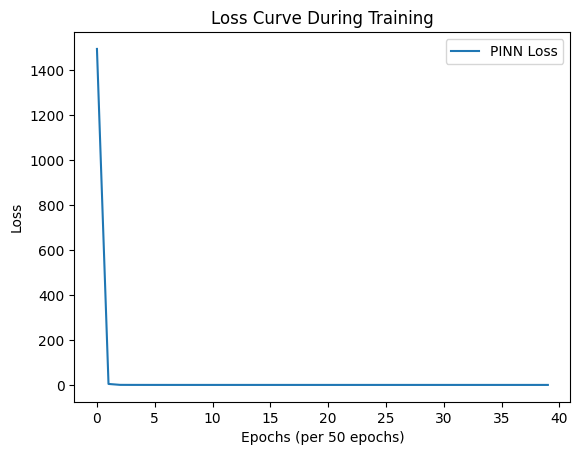

In [ ]:
import matplotlib.pyplot as plt

plt.plot(loss_list2, label='PINN Loss')

plt.title('Loss Curve During Training')
plt.xlabel('Epochs (per 50 epochs)')
plt.ylabel('Loss')

plt.legend()

plt.show()

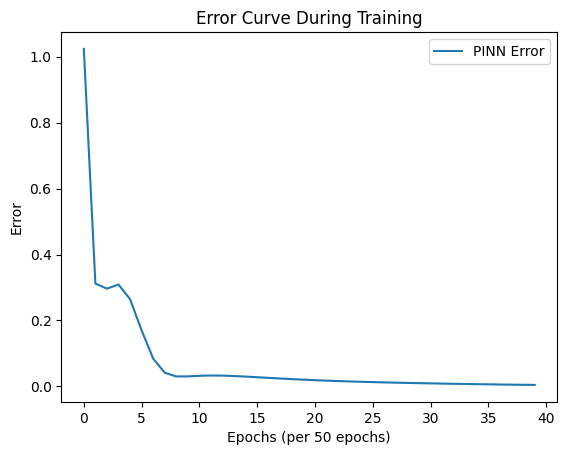

In [ ]:
import matplotlib.pyplot as plt

plt.plot(error_list2, label='PINN Error')

plt.title('Error Curve During Training')
plt.xlabel('Epochs (per 50 epochs)')
plt.ylabel('Error')

plt.legend()

plt.show()

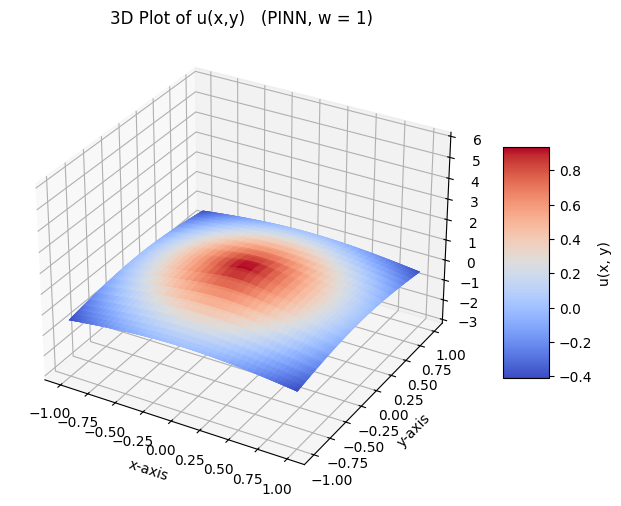

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

# Set a fixed w value
w_fixed = 1.0

# Generate theta values for a circular distribution
theta = np.linspace(0, 2 * np.pi, 100)

# Generate (x, y) coordinates on the circle
x_plot = np.cos(theta)
y_plot = np.sin(theta)

# Create a 2D grid
x_plot_grid, y_plot_grid = np.meshgrid(x_plot, y_plot)

# Flatten the grid for network input
pt_x_plot = torch.tensor(x_plot_grid.ravel(), dtype=torch.float32).to(device).view(-1, 1)
pt_y_plot = torch.tensor(y_plot_grid.ravel(), dtype=torch.float32).to(device).view(-1, 1)
pt_w_plot = torch.full((pt_x_plot.size(0), 1), w_fixed, device=device)

# Calculate u(x, y)
u_plot = (1 - torch.sqrt(pt_x_plot**2 + pt_y_plot**2)) * net_pinn(pt_x_plot, pt_y_plot, pt_w_plot)

# Reshape u_plot for plotting
u_plot_reshaped = u_plot.detach().cpu().numpy().reshape(x_plot_grid.shape)

# Plotting
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(x_plot_grid, y_plot_grid, u_plot_reshaped, cmap='coolwarm')  # Set color map to 'coolwarm'
ax.set_zlim(-3,6)

# Add color bar
cbar = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)
cbar.set_label("u(x, y)")

# Set labels and title
ax.set_xlabel("x-axis")
ax.set_ylabel("y-axis")
ax.set_title("3D Plot of u(x,y)   (PINN, w = 1)")

plt.show()

#**DRM & PINN** (mix)


In [ ]:
M = 128

class Net2D(nn.Module):
    def __init__(self):
        super(Net2D, self).__init__()
        torch.manual_seed(7)  # Fix Initial Parameter
        self.hidden_layer1 = nn.Linear(3, M)
        self.hidden_layer2 = nn.Linear(M, M)
        self.hidden_layer3 = nn.Linear(M, M)
        self.hidden_layer4 = nn.Linear(M, M)
        self.output_layer = nn.Linear(M, 1)

        # Define GELU activation function
        self.gelu = nn.GELU()

    def forward(self, x, y, w):
        inputs = torch.cat([x, y, w], axis=1)  # Concatenate
        layer1_out = self.gelu(self.hidden_layer1(inputs))
        layer2_out = self.gelu(self.hidden_layer2(layer1_out))
        layer3_out = self.gelu(self.hidden_layer3(layer2_out))
        layer4_out = self.gelu(self.hidden_layer4(layer3_out))
        output = self.output_layer(layer4_out)  # For regression, no activation is used in output layer

        return output

net_2d = Net2D()
net_2d = net_2d.to(device)
optimizer = torch.optim.Adam(net_2d.parameters(), lr = 0.001)

def drm_loss(x, y, w, net):
    # 네트워크의 출력 계산
    u = (1 - torch.sqrt(x**2 + y**2)) * net(x, y, w)

    # u를 x, y에 대해 미분 (grad_u = ∇u)
    grad_u = torch.autograd.grad(u, [x, y], grad_outputs=torch.ones_like(u), create_graph=True)

    # ∇u는 두 개의 미분 값으로 반환되므로 이를 결합하여 벡터 형식으로 만듦
    grad_u = torch.cat(grad_u, dim=1)  # grad_u는 [∂u/∂x, ∂u/∂y]

    # ∇u의 크기 계산 (|∇u|)
    grad_u_norm = torch.norm(grad_u, dim=1, keepdim=True)

    # f(w, x, y) 계산
    f = w**2 / torch.sqrt(x**2 + y**2)

    # drm loss
    energy = ((1/3) * (grad_u_norm**3) - f * u).sum() / 200000

    return energy

def pinn_loss(x, y, w, net):
    # 네트워크의 출력 계산 (u 값)
    u = (1 - torch.sqrt(x**2 + y**2)) * net(x, y, w)

    # u를 x, y에 대해 미분 (grad_u = ∇u)
    grad_u = torch.autograd.grad(u, [x, y], grad_outputs=torch.ones_like(u), create_graph=True)

    # ∇u는 두 개의 미분 값으로 반환되므로 이를 결합하여 벡터 형식으로 만듦
    grad_u = torch.cat(grad_u, dim=1)  # grad_u는 [∂u/∂x, ∂u/∂y]

    # ∇u의 크기 계산 (|∇u|)
    grad_u_norm = torch.norm(grad_u, dim=1, keepdim=True)

    # 3-Laplacian: div(|∇u| ∇u)를 계산 (x, y에 대해서만)
    div_term = grad_u_norm * grad_u
    div_x = torch.autograd.grad(div_term[:, 0], x, grad_outputs=torch.ones_like(div_term[:, 0]), create_graph=True)[0]
    div_y = torch.autograd.grad(div_term[:, 1], y, grad_outputs=torch.ones_like(div_term[:, 1]), create_graph=True)[0]

    # 발산은 x, y에 대한 미분의 합
    div = div_x + div_y

    # f(w, x, y) 계산
    f = w**2 / torch.sqrt(x**2 + y**2)

    # PINN loss = MSE(div + f)
    loss = torch.mean((div + f)**2)

    return loss

# 각도 theta의 분포 생성 (예: -0.99에서 0.99 사이에서 각도를 생성)
theta_collocation = np.linspace(0, 2 * np.pi, 100)

# 원 위의 (x, y) 좌표 생성
x_collocation = np.cos(theta_collocation)
y_collocation = np.sin(theta_collocation)

# 임의의 w_collocation 생성
w_collocation = np.random.uniform(0.1, 6, 20)

# 메시 그리드 생성
x_grid, y_grid, w_grid = np.meshgrid(x_collocation, y_collocation, w_collocation, indexing='ij')

# 메시 그리드를 평탄화하여 모든 조합을 생성
x_combined = x_grid.ravel().reshape(-1, 1)
y_combined = y_grid.ravel().reshape(-1, 1)
w_combined = w_grid.ravel().reshape(-1, 1)

# PyTorch 텐서로 변환
pt_x_collocation = Variable(torch.from_numpy(x_combined).float(), requires_grad=True).to(device)
pt_y_collocation = Variable(torch.from_numpy(y_combined).float(), requires_grad=True).to(device)
pt_w_collocation = Variable(torch.from_numpy(w_combined).float(), requires_grad=True).to(device)

# 반지름 1인 원 안에서 임의의 점 생성
r = np.random.uniform(0, 1, 20)  # 0과 1 사이의 값으로 반지름 선택
theta = np.random.uniform(0, 2 * np.pi, 20)  # 0과 2pi 사이에서 각도 선택

# 원 안의 (x, y) 좌표 생성
obx = r * np.cos(theta)
oby = r * np.sin(theta)
obw = np.linspace(0.1, 6, 20)

# 3D meshgrid 생성
ms_x, ms_y, ms_w = np.meshgrid(obx, oby, obw)

# 1D 배열로 변환
obx1 = np.ravel(ms_x).reshape(-1, 1)
oby1 = np.ravel(ms_y).reshape(-1, 1)
obw1 = np.ravel(ms_w).reshape(-1, 1)

# 조건 적용: x^2 + y^2 <= 1
mask = (obx1**2 + oby1**2 <= 1).flatten()
filtered_obx1 = obx1[mask]
filtered_oby1 = oby1[mask]
filtered_obw1 = obw1[mask]

ob_x = Variable(torch.from_numpy(filtered_obx1).float(), requires_grad=True).to(device)
ob_y = Variable(torch.from_numpy(filtered_oby1).float(), requires_grad=True).to(device)
ob_w = Variable(torch.from_numpy(filtered_obw1).float(), requires_grad=True).to(device)

iterations = 2000
previous_validation_loss = 99999999.0

In [ ]:
for epoch in range(iterations):
    optimizer.zero_grad() # to make the gradients zero

    mix = (0.3 * drm_loss(pt_x_collocation, pt_y_collocation, pt_w_collocation, net_2d)
            + 0.7 * pinn_loss(pt_x_collocation, pt_y_collocation, pt_w_collocation, net_2d))

    mix.backward() # This is for computing gradients using backward propagation
    optimizer.step() # Using Adam

    ##--------------------------------------Print relative error(Not learn)-----------------------------------------##
    if epoch % 50 == 0:
        pt_u = (1 - torch.sqrt(ob_x**2 + ob_y**2)) * net_2d(ob_x, ob_y, ob_w)

        # solution 계산
        solution = ob_w * (1 - torch.sqrt(ob_x**2 + ob_y**2))

        error_mix = ((((solution - pt_u)**2).sum()) / ((solution**2).sum()))**(0.5)

        print("Epoch : ",epoch)
        print("mix_loss : ",mix.item())
        print("Relative L2 error:", error_mix)
        print("---------------------------------------------------")

        loss_list3.append(mix.item())
        error_list3.append(error_mix.item())

net_mix=net_2d

Epoch :  0
mix_loss :  498.0946960449219
Relative L2 error: tensor(0.9966, device='cuda:0', grad_fn=<PowBackward0>)
---------------------------------------------------
Epoch :  50
mix_loss :  1.803715467453003
Relative L2 error: tensor(0.0480, device='cuda:0', grad_fn=<PowBackward0>)
---------------------------------------------------
Epoch :  100
mix_loss :  0.4043475091457367
Relative L2 error: tensor(0.0230, device='cuda:0', grad_fn=<PowBackward0>)
---------------------------------------------------
Epoch :  150
mix_loss :  0.34609249234199524
Relative L2 error: tensor(0.0194, device='cuda:0', grad_fn=<PowBackward0>)
---------------------------------------------------
Epoch :  200
mix_loss :  0.3285640478134155
Relative L2 error: tensor(0.0147, device='cuda:0', grad_fn=<PowBackward0>)
---------------------------------------------------
Epoch :  250
mix_loss :  0.31583961844444275
Relative L2 error: tensor(0.0090, device='cuda:0', grad_fn=<PowBackward0>)
-----------------------------

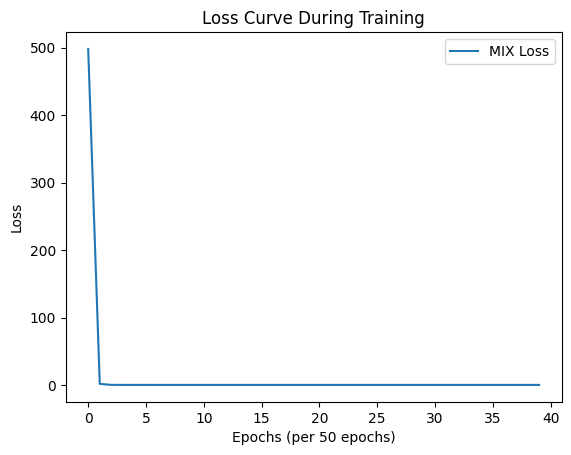

In [ ]:
import matplotlib.pyplot as plt

plt.plot(loss_list3, label='MIX Loss')

plt.title('Loss Curve During Training')
plt.xlabel('Epochs (per 50 epochs)')
plt.ylabel('Loss')

plt.legend()

plt.show()

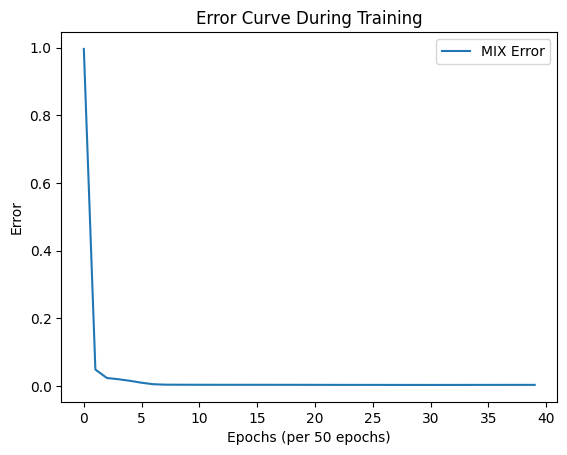

In [ ]:
import matplotlib.pyplot as plt

plt.plot(error_list3, label='MIX Error')

plt.title('Error Curve During Training')
plt.xlabel('Epochs (per 50 epochs)')
plt.ylabel('Error')

plt.legend()

plt.show()

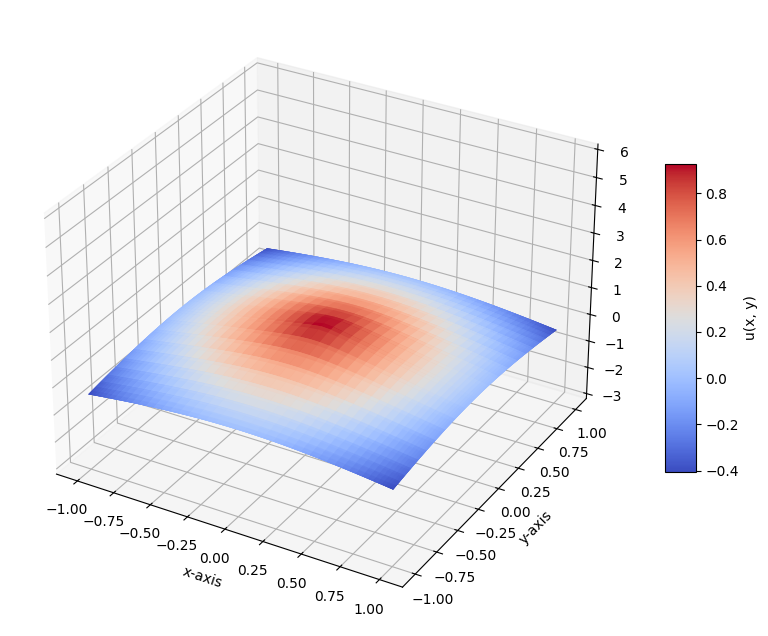

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

# Set a fixed w value
w_fixed = 1.0

# Generate theta values for a circular distribution
theta = np.linspace(0, 2 * np.pi, 100)

# Generate (x, y) coordinates on the circle
x_plot = np.cos(theta)
y_plot = np.sin(theta)

# Create a 2D grid
x_plot_grid, y_plot_grid = np.meshgrid(x_plot, y_plot)

# Flatten the grid for network input
pt_x_plot = torch.tensor(x_plot_grid.ravel(), dtype=torch.float32).to(device).view(-1, 1)
pt_y_plot = torch.tensor(y_plot_grid.ravel(), dtype=torch.float32).to(device).view(-1, 1)
pt_w_plot = torch.full((pt_x_plot.size(0), 1), w_fixed, device=device)

# Calculate u(x, y)
u_plot = (1 - torch.sqrt(pt_x_plot**2 + pt_y_plot**2)) * net_mix(pt_x_plot, pt_y_plot, pt_w_plot)

# Reshape u_plot for plotting
u_plot_reshaped = u_plot.detach().cpu().numpy().reshape(x_plot_grid.shape)

# Plotting
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(x_plot_grid, y_plot_grid, u_plot_reshaped, cmap='coolwarm')  # Set color map to 'coolwarm'
ax.set_zlim(-3,6)

# Add color bar
cbar = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)
cbar.set_label("u(x, y)")

# Set labels and title
ax.set_xlabel("x-axis")
ax.set_ylabel("y-axis")
#ax.set_title("3D Plot of u(x,y)   (MIX, w = 1)")

plt.show()

# plots

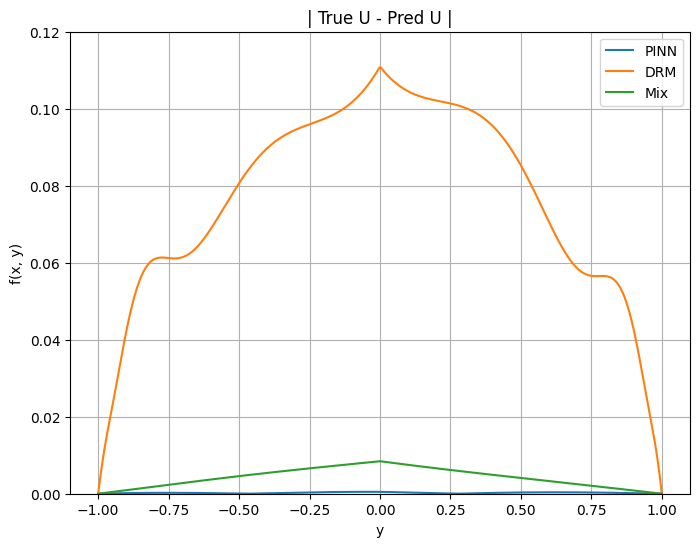

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np
import torch
from torch.autograd import Variable

ax = fig.add_subplot(projection='3d')

# Set a fixed w value
w = 1

y_np = np.linspace(-1, 1, 500)
w_np = w*np.ones_like(y_np)
x_np = np.zeros_like(y_np)


x = Variable(torch.from_numpy(x_np).float().unsqueeze(1), requires_grad=True).to(device)
y = Variable(torch.from_numpy(y_np).float().unsqueeze(1), requires_grad=True).to(device)
w = Variable(torch.from_numpy(w_np).float().unsqueeze(1), requires_grad=True).to(device)


# f(x, y) 계산
z_PINN = torch.abs(w * (1 - torch.sqrt(y**2)) - (1 - torch.sqrt(y**2)) * net_pinn(x, y, w)).cpu().detach().numpy()
z_DRM = torch.abs(w * (1 - torch.sqrt(y**2)) - (1 - torch.sqrt(y**2)) * net_drm(x, y, w)).cpu().detach().numpy()
z_Mix = torch.abs(w * (1 - torch.sqrt(y**2)) - (1 - torch.sqrt(y**2)) * net_mix(x, y, w)).cpu().detach().numpy()

# 2D 그래프로 시각화
plt.figure(figsize=(8, 6))
plt.plot(y_np, z_PINN, label=f'PINN')
plt.plot(y_np, z_DRM, label=f'DRM')
plt.plot(y_np, z_Mix, label=f'Mix')

plt.title("| True U - Pred U |")
plt.xlabel("y")
plt.ylabel("f(x, y)")
plt.ylim(0,0.12)
plt.legend()
plt.grid()
plt.show()

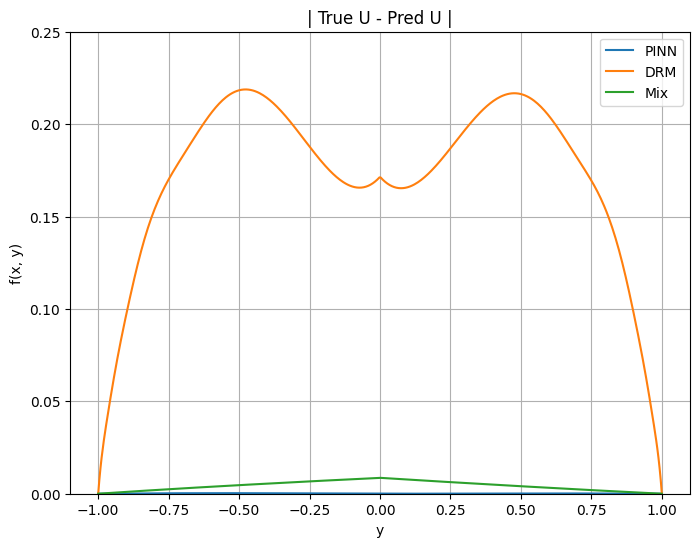

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np
import torch
from torch.autograd import Variable

ax = fig.add_subplot(projection='3d')

# Set a fixed w value
w = 3

y_np = np.linspace(-1, 1, 500)
w_np = w*np.ones_like(y_np)
x_np = np.zeros_like(y_np)


x = Variable(torch.from_numpy(x_np).float().unsqueeze(1), requires_grad=True).to(device)
y = Variable(torch.from_numpy(y_np).float().unsqueeze(1), requires_grad=True).to(device)
w = Variable(torch.from_numpy(w_np).float().unsqueeze(1), requires_grad=True).to(device)


# f(x, y) 계산
z_PINN = torch.abs(w * (1 - torch.sqrt(y**2)) - (1 - torch.sqrt(y**2)) * net_pinn(x, y, w)).cpu().detach().numpy()
z_DRM = torch.abs(w * (1 - torch.sqrt(y**2)) - (1 - torch.sqrt(y**2)) * net_drm(x, y, w)).cpu().detach().numpy()
z_Mix = torch.abs(w * (1 - torch.sqrt(y**2)) - (1 - torch.sqrt(y**2)) * net_mix(x, y, w)).cpu().detach().numpy()

# 2D 그래프로 시각화
plt.figure(figsize=(8, 6))
plt.plot(y_np, z_PINN, label=f'PINN')
plt.plot(y_np, z_DRM, label=f'DRM')
plt.plot(y_np, z_Mix, label=f'Mix')

plt.title("| True U - Pred U |")
plt.xlabel("y")
plt.ylabel("f(x, y)")
plt.ylim(0,0.25)
plt.legend()
plt.grid()
plt.show()

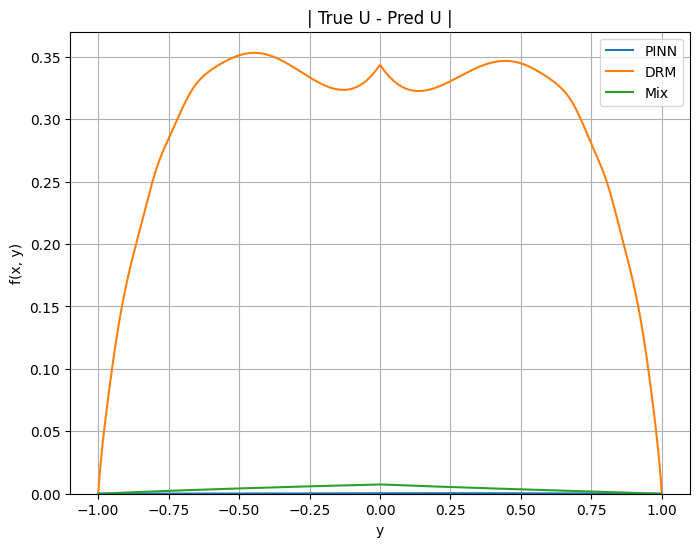

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np
import torch
from torch.autograd import Variable

ax = fig.add_subplot(projection='3d')

# Set a fixed w value
w = 5

y_np = np.linspace(-1, 1, 500)
w_np = w*np.ones_like(y_np)
x_np = np.zeros_like(y_np)


x = Variable(torch.from_numpy(x_np).float().unsqueeze(1), requires_grad=True).to(device)
y = Variable(torch.from_numpy(y_np).float().unsqueeze(1), requires_grad=True).to(device)
w = Variable(torch.from_numpy(w_np).float().unsqueeze(1), requires_grad=True).to(device)


# f(x, y) 계산
z_PINN = torch.abs(w * (1 - torch.sqrt(y**2)) - (1 - torch.sqrt(y**2)) * net_pinn(x, y, w)).cpu().detach().numpy()
z_DRM = torch.abs(w * (1 - torch.sqrt(y**2)) - (1 - torch.sqrt(y**2)) * net_drm(x, y, w)).cpu().detach().numpy()
z_Mix = torch.abs(w * (1 - torch.sqrt(y**2)) - (1 - torch.sqrt(y**2)) * net_mix(x, y, w)).cpu().detach().numpy()

# 2D 그래프로 시각화
plt.figure(figsize=(8, 6))
plt.plot(y_np, z_PINN, label=f'PINN')
plt.plot(y_np, z_DRM, label=f'DRM')
plt.plot(y_np, z_Mix, label=f'Mix')

plt.title("| True U - Pred U |")
plt.xlabel("y")
plt.ylabel("f(x, y)")
plt.ylim(0,0.37)
plt.legend()
plt.grid()
plt.show()

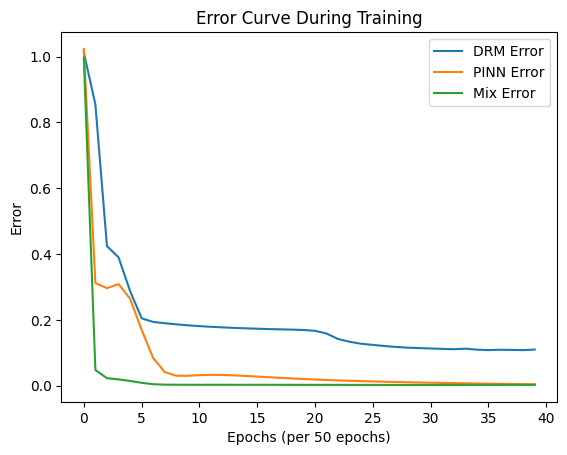

In [ ]:
import matplotlib.pyplot as plt

plt.plot(error_list1, label='DRM Error')
plt.plot(error_list2, label='PINN Error')
plt.plot(error_list3, label='Mix Error')

plt.title('Error Curve During Training')
plt.xlabel('Epochs (per 50 epochs)')
plt.ylabel('Error')

plt.legend()

plt.show()